# Préparation du Dataset Cassava - Fusion de TOUS les Datasets

Ce notebook fusionne tous les datasets cassava disponibles (~33,000 images) et crée un dataset VQA équilibré pour l'entraînement du modèle Qwen3-VL.

## Sources de Données

1. **Kaggle**: 21,397 images (data/raw/train_images + train.csv)
2. **Cassava Train**: ~5,600 images (data/cassava/train/)
3. **CBSD Datasets**: ~6,000 images (data/cbsd-1, data/cbsd-2)
4. **CMD Datasets**: ~5,000 images (data/cmd_001 à cmd_005)
5. **Healthy Datasets**: ~1,100 images (data/healthy_001, healthy_002)

## Objectifs

- Fusionner tous les datasets avec leurs labels
- Créer conversations VQA (format Qwen3-VL)
- Split stratifié train/val/test (80/10/10)
- Équilibrer les classes (sous-échantillonnage CMD, suréchantillonnage CBB/CGM)
- Générer ~35,000 images finales bien équilibrées

## 1. Imports et Configuration

In [1]:
import os
import json
import hashlib
import random
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Tuple

import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
BASE_DIR = Path("/home/hounfodjidagba/learning/cassava")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "new_implementation" / "data" / "stage1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mapping des labels
LABEL_MAPPING = {
    0: "Cassava Bacterial Blight (CBB)",
    1: "Cassava Brown Streak Disease (CBSD)",
    2: "Cassava Green Mottle (CGM)",
    3: "Cassava Mosaic Disease (CMD)",
    4: "Healthy"
}

# Mapping inverse nom → label
NAME_TO_LABEL = {
    "cbb": 0,
    "cbsd": 1,
    "cgm": 2,
    "cmd": 3,
    "healthy": 4
}

# Seed pour reproductibilité
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Label mapping: {LABEL_MAPPING}")

Base directory: /home/hounfodjidagba/learning/cassava
Output directory: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1
Label mapping: {0: 'Cassava Bacterial Blight (CBB)', 1: 'Cassava Brown Streak Disease (CBSD)', 2: 'Cassava Green Mottle (CGM)', 3: 'Cassava Mosaic Disease (CMD)', 4: 'Healthy'}


## 2. Fonctions Utilitaires

In [2]:
def compute_image_hash(image_path: Path) -> str:
    """Calcule le hash MD5 d'une image pour détecter les doublons."""
    try:
        with open(image_path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except Exception as e:
        print(f"Erreur lors du calcul du hash pour {image_path}: {e}")
        return None

def get_disease_description(label: int) -> str:
    """Retourne une description de la maladie."""
    descriptions = {
        0: "Cassava Bacterial Blight (CBB) is a bacterial disease that causes water-soaked lesions on leaves, wilting, and stem cankers. It can lead to severe yield losses if not managed properly.",
        1: "Cassava Brown Streak Disease (CBSD) causes brown streaks on stems and necrotic lesions in tubers, severely affecting cassava yield and quality. It is transmitted by whiteflies.",
        2: "Cassava Green Mottle (CGM) is characterized by green mottling patterns on leaves. It affects plant vigor and can reduce yields.",
        3: "Cassava Mosaic Disease (CMD) is one of the most devastating cassava diseases, causing severe mosaic patterns, leaf distortion, and stunted growth. It is transmitted by whiteflies.",
        4: "This cassava plant appears healthy with no visible disease symptoms. Healthy plants have uniform green leaves without discoloration, lesions, or distortion."
    }
    return descriptions.get(label, "Unknown disease.")

def create_vqa_conversation(image_path: str, label: int, question_template: str = None) -> Dict:
    """Crée une conversation VQA pour une image."""
    if question_template is None:
        question_template = "What cassava disease is shown in this image?"
    
    disease_name = LABEL_MAPPING[label]
    disease_desc = get_disease_description(label)
    
    return {
        "from": "user",
        "value": f"Picture 1: <img>{image_path}</img>\n{question_template}"
    }, {
        "from": "assistant",
        "value": f"Disease: {disease_name}\n\n{disease_desc}"
    }

print("Fonctions utilitaires chargées.")

Fonctions utilitaires chargées.


## 3. Chargement de Tous les Datasets

In [3]:
# Structure pour stocker tous les échantillons
all_samples = []
image_hashes = set()  # Pour détecter les doublons

print("=== Chargement des datasets ===")
print()

=== Chargement des datasets ===



### 3.1 Dataset 1: Kaggle (train.csv + train_images)

In [4]:
print("[1/5] Chargement Kaggle dataset...")

kaggle_csv = DATA_DIR / "raw" / "train.csv"
kaggle_images_dir = DATA_DIR / "raw" / "train_images"

if kaggle_csv.exists():
    df_kaggle = pd.read_csv(kaggle_csv)
    
    for idx, row in tqdm(df_kaggle.iterrows(), total=len(df_kaggle), desc="Kaggle"):
        image_path = kaggle_images_dir / row['image_id']
        
        if not image_path.exists():
            continue
        
        # Calculer hash pour déduplication
        img_hash = compute_image_hash(image_path)
        if img_hash is None or img_hash in image_hashes:
            continue
        
        image_hashes.add(img_hash)
        
        all_samples.append({
            'image_path': str(image_path.absolute()),
            'label': int(row['label']),
            'source': 'kaggle',
            'image_id': f"kaggle_{row['image_id']}"
        })
    
    print(f"✓ Kaggle: {len([s for s in all_samples if s['source'] == 'kaggle'])} images chargées")
else:
    print(f"✗ Fichier non trouvé: {kaggle_csv}")

print(f"Total jusqu'ici: {len(all_samples)} images")
print()

[1/5] Chargement Kaggle dataset...


Kaggle: 100%|██████████| 21397/21397 [00:10<00:00, 2027.45it/s]

✓ Kaggle: 21397 images chargées
Total jusqu'ici: 21397 images



### 3.2 Dataset 2: Cassava Train (structure par répertoires)

In [5]:
print("[2/5] Chargement Cassava Train dataset...")

cassava_train_dir = DATA_DIR / "cassava" / "train"

if cassava_train_dir.exists():
    for class_folder in cassava_train_dir.iterdir():
        if not class_folder.is_dir():
            continue
        
        class_name = class_folder.name.lower()
        if class_name not in NAME_TO_LABEL:
            print(f"  Classe inconnue ignorée: {class_name}")
            continue
        
        label = NAME_TO_LABEL[class_name]
        count = 0
        
        for img_file in class_folder.glob("*.jpg"):
            img_hash = compute_image_hash(img_file)
            if img_hash is None or img_hash in image_hashes:
                continue
            
            image_hashes.add(img_hash)
            
            all_samples.append({
                'image_path': str(img_file.absolute()),
                'label': label,
                'source': f'cassava_train_{class_name}',
                'image_id': f"cassava_{class_name}_{img_file.stem}"
            })
            count += 1
        
        print(f"  {class_name}: {count} images")
    
    print(f"✓ Cassava Train: total chargé")
else:
    print(f"✗ Dossier non trouvé: {cassava_train_dir}")

print(f"Total jusqu'ici: {len(all_samples)} images")
print()

[2/5] Chargement Cassava Train dataset...
  cmd: 2656 images
  cgm: 773 images
  healthy: 316 images
  cbb: 462 images
  cbsd: 1434 images
✓ Cassava Train: total chargé
Total jusqu'ici: 27038 images



### 3.3 Dataset 3: CBSD Datasets (cbsd-1, cbsd-2)

In [6]:
print("[3/5] Chargement CBSD datasets...")

cbsd_dirs = [DATA_DIR / "cbsd-1", DATA_DIR / "cbsd-2"]
label_cbsd = 1  # CBSD

for cbsd_dir in cbsd_dirs:
    if not cbsd_dir.exists():
        print(f"  ✗ {cbsd_dir.name}: dossier non trouvé")
        continue
    
    count = 0
    for img_file in cbsd_dir.glob("*.jpg"):
        img_hash = compute_image_hash(img_file)
        if img_hash is None or img_hash in image_hashes:
            continue
        
        image_hashes.add(img_hash)
        
        all_samples.append({
            'image_path': str(img_file.absolute()),
            'label': label_cbsd,
            'source': cbsd_dir.name,
            'image_id': f"{cbsd_dir.name}_{img_file.stem}"
        })
        count += 1
    
    print(f"  {cbsd_dir.name}: {count} images")

print(f"Total jusqu'ici: {len(all_samples)} images")
print()

[3/5] Chargement CBSD datasets...
  cbsd-1: 1787 images
  cbsd-2: 1210 images
Total jusqu'ici: 30035 images



### 3.4 Dataset 4: CMD Datasets (cmd_001 à cmd_005)

In [7]:
print("[4/5] Chargement CMD datasets...")

cmd_dirs = [DATA_DIR / f"cmd_{i:03d}" for i in range(1, 6)]
label_cmd = 3  # CMD

for cmd_dir in cmd_dirs:
    if not cmd_dir.exists():
        print(f"  ✗ {cmd_dir.name}: dossier non trouvé")
        continue
    
    count = 0
    for img_file in cmd_dir.glob("*.jpg"):
        img_hash = compute_image_hash(img_file)
        if img_hash is None or img_hash in image_hashes:
            continue
        
        image_hashes.add(img_hash)
        
        all_samples.append({
            'image_path': str(img_file.absolute()),
            'label': label_cmd,
            'source': cmd_dir.name,
            'image_id': f"{cmd_dir.name}_{img_file.stem}"
        })
        count += 1
    
    print(f"  {cmd_dir.name}: {count} images")

print(f"Total jusqu'ici: {len(all_samples)} images")
print()

[4/5] Chargement CMD datasets...
  cmd_001: 1211 images
  cmd_002: 1224 images
  cmd_003: 1218 images
  cmd_004: 941 images
  cmd_005: 400 images
Total jusqu'ici: 35029 images



### 3.5 Dataset 5: Healthy Datasets (healthy_001, healthy_002)

In [8]:
print("[5/5] Chargement Healthy datasets...")

healthy_dirs = [DATA_DIR / "healthy_001", DATA_DIR / "healthy_002"]
label_healthy = 4  # Healthy

for healthy_dir in healthy_dirs:
    if not healthy_dir.exists():
        print(f"  ✗ {healthy_dir.name}: dossier non trouvé")
        continue
    
    count = 0
    for img_file in healthy_dir.glob("*.jpg"):
        img_hash = compute_image_hash(img_file)
        if img_hash is None or img_hash in image_hashes:
            continue
        
        image_hashes.add(img_hash)
        
        all_samples.append({
            'image_path': str(img_file.absolute()),
            'label': label_healthy,
            'source': healthy_dir.name,
            'image_id': f"{healthy_dir.name}_{img_file.stem}"
        })
        count += 1
    
    print(f"  {healthy_dir.name}: {count} images")

print()
print(f"="*60)
print(f"TOTAL FINAL: {len(all_samples)} images uniques chargées")
print(f"Doublons détectés et retirés: {len(image_hashes) - len(all_samples) if len(image_hashes) > len(all_samples) else 0}")
print(f"="*60)

[5/5] Chargement Healthy datasets...
  healthy_001: 597 images
  healthy_002: 522 images

TOTAL FINAL: 36148 images uniques chargées
Doublons détectés et retirés: 0


## 4. Analyse de la Distribution des Classes


=== Distribution des Classes (AVANT Équilibrage) ===

Cassava Bacterial Blight (CBB)                (Label 0):   1549 images ( 4.29%)
Cassava Brown Streak Disease (CBSD)           (Label 1):   6620 images (18.31%)
Cassava Green Mottle (CGM)                    (Label 2):   3159 images ( 8.74%)
Cassava Mosaic Disease (CMD)                  (Label 3):  20808 images (57.56%)
Healthy                                       (Label 4):   4012 images (11.10%)

TOTAL: 36148 images


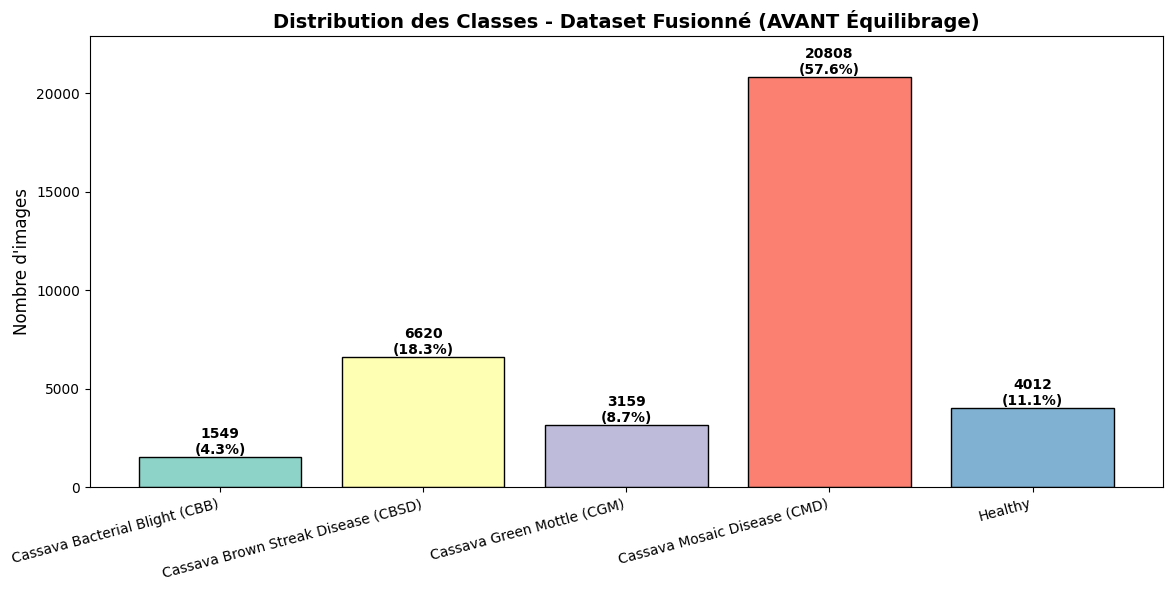


✓ Graphique sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1/distribution_before_balancing.png


In [9]:
# Compter les classes
label_counts = Counter([s['label'] for s in all_samples])
total = len(all_samples)

print("\n=== Distribution des Classes (AVANT Équilibrage) ===")
print()
for label in sorted(label_counts.keys()):
    count = label_counts[label]
    percentage = (count / total) * 100
    print(f"{LABEL_MAPPING[label]:45s} (Label {label}): {count:6d} images ({percentage:5.2f}%)")

print(f"\nTOTAL: {total} images")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
labels_names = [LABEL_MAPPING[i] for i in sorted(label_counts.keys())]
counts = [label_counts[i] for i in sorted(label_counts.keys())]
colors = plt.cm.Set3(range(len(labels_names)))

bars = ax.bar(labels_names, counts, color=colors, edgecolor='black')
ax.set_ylabel('Nombre d\'images', fontsize=12)
ax.set_title('Distribution des Classes - Dataset Fusionné (AVANT Équilibrage)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.1)
plt.xticks(rotation=15, ha='right')

# Ajouter les valeurs sur les barres
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution_before_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Graphique sauvegardé: {OUTPUT_DIR / 'distribution_before_balancing.png'}")

## 5. Split Stratifié Train/Val/Test (80/10/10)

In [10]:
print("\n=== Split Stratifié Train/Val/Test ===")
print()

# Séparer par label pour split stratifié
samples_by_label = defaultdict(list)
for sample in all_samples:
    samples_by_label[sample['label']].append(sample)

train_samples = []
val_samples = []
test_samples = []

for label, samples in samples_by_label.items():
    # Mélanger
    random.shuffle(samples)
    
    # Split 80/10/10
    n_total = len(samples)
    n_train = int(n_total * 0.8)
    n_val = int(n_total * 0.1)
    
    train = samples[:n_train]
    val = samples[n_train:n_train+n_val]
    test = samples[n_train+n_val:]
    
    train_samples.extend(train)
    val_samples.extend(val)
    test_samples.extend(test)
    
    print(f"{LABEL_MAPPING[label]:45s}: {len(train):5d} train / {len(val):4d} val / {len(test):4d} test")

print(f"\nTOTAL: {len(train_samples)} train / {len(val_samples)} val / {len(test_samples)} test")
print(f"Split: {len(train_samples)/len(all_samples)*100:.1f}% / {len(val_samples)/len(all_samples)*100:.1f}% / {len(test_samples)/len(all_samples)*100:.1f}%")


=== Split Stratifié Train/Val/Test ===

Cassava Bacterial Blight (CBB)               :  1239 train /  154 val /  156 test
Cassava Mosaic Disease (CMD)                 : 16646 train / 2080 val / 2082 test
Cassava Brown Streak Disease (CBSD)          :  5296 train /  662 val /  662 test
Cassava Green Mottle (CGM)                   :  2527 train /  315 val /  317 test
Healthy                                      :  3209 train /  401 val /  402 test

TOTAL: 28917 train / 3612 val / 3619 test
Split: 80.0% / 10.0% / 10.0%


## 6. Équilibrage des Classes

### Stratégie:
- **Sous-échantillonnage CMD**: 63% → 36% (garder 12,000 images)
- **Suréchantillonnage CBB**: répliquer 3x avec variations de questions
- **Suréchantillonnage CGM**: répliquer 2x avec variations de questions

In [11]:
# Variations de questions pour suréchantillonnage
QUESTION_VARIATIONS = [
    "What cassava disease is shown in this image?",
    "What disease affects this cassava plant?",
    "Identify the cassava disease in this image.",
    "Can you diagnose this cassava leaf?",
    "What's wrong with this cassava plant?",
    "Which disease is present in this cassava leaf?",
    "Analyze this cassava leaf and identify any disease.",
    "What cassava disease do you see here?",
    "Diagnose this cassava plant disease."
]

print("\n=== Équilibrage des Classes ===")
print()

# Séparer train par label
train_by_label = defaultdict(list)
for sample in train_samples:
    train_by_label[sample['label']].append(sample)

# Sous-échantillonnage CMD (label 3)
cmd_samples = train_by_label[3]
n_cmd_keep = min(12000, len(cmd_samples))
random.shuffle(cmd_samples)
train_by_label[3] = cmd_samples[:n_cmd_keep]
print(f"CMD: sous-échantillonné de {len(cmd_samples)} → {n_cmd_keep} images")

# Suréchantillonnage CBB (label 0) - 3x
cbb_samples = train_by_label[0]
cbb_replicated = []
for sample in cbb_samples:
    # Original
    cbb_replicated.append({**sample, 'question_variant': 0})
    # 2 répliques avec questions différentes
    for i in range(1, 3):
        cbb_replicated.append({**sample, 'question_variant': i})
train_by_label[0] = cbb_replicated
print(f"CBB: suréchantillonné de {len(cbb_samples)} → {len(cbb_replicated)} images (3x)")

# Suréchantillonnage CGM (label 2) - 2x
cgm_samples = train_by_label[2]
cgm_replicated = []
for sample in cgm_samples:
    # Original
    cgm_replicated.append({**sample, 'question_variant': 0})
    # 1 réplique avec question différente
    cgm_replicated.append({**sample, 'question_variant': 1})
train_by_label[2] = cgm_replicated
print(f"CGM: suréchantillonné de {len(cgm_samples)} → {len(cgm_replicated)} images (2x)")

# Reconstruire train_samples équilibré
train_samples_balanced = []
for label, samples in train_by_label.items():
    train_samples_balanced.extend(samples)

# Mélanger
random.shuffle(train_samples_balanced)

print()
print(f"TOTAL APRÈS ÉQUILIBRAGE: {len(train_samples_balanced)} images train")
print()

# Nouvelle distribution
balanced_counts = Counter([s['label'] for s in train_samples_balanced])
total_balanced = len(train_samples_balanced)

print("Distribution APRÈS Équilibrage:")
for label in sorted(balanced_counts.keys()):
    count = balanced_counts[label]
    percentage = (count / total_balanced) * 100
    print(f"{LABEL_MAPPING[label]:45s}: {count:6d} ({percentage:5.2f}%)")


=== Équilibrage des Classes ===

CMD: sous-échantillonné de 16646 → 12000 images
CBB: suréchantillonné de 1239 → 3717 images (3x)
CGM: suréchantillonné de 2527 → 5054 images (2x)

TOTAL APRÈS ÉQUILIBRAGE: 29276 images train

Distribution APRÈS Équilibrage:
Cassava Bacterial Blight (CBB)               :   3717 (12.70%)
Cassava Brown Streak Disease (CBSD)          :   5296 (18.09%)
Cassava Green Mottle (CGM)                   :   5054 (17.26%)
Cassava Mosaic Disease (CMD)                 :  12000 (40.99%)
Healthy                                      :   3209 (10.96%)


## 7. Visualisation Distribution Équilibrée

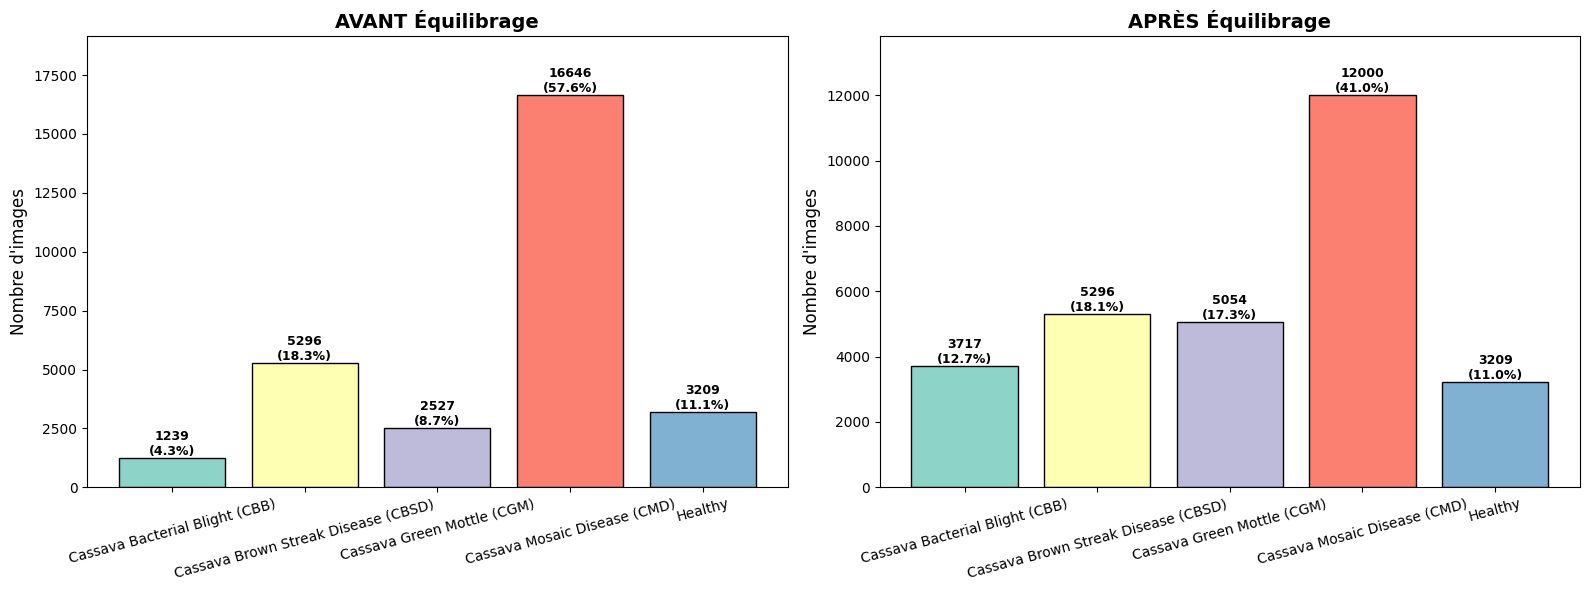


✓ Graphique sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1/distribution_comparison.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Avant équilibrage
train_counts_before = Counter([s['label'] for s in train_samples])
labels_names = [LABEL_MAPPING[i] for i in sorted(train_counts_before.keys())]
counts_before = [train_counts_before[i] for i in sorted(train_counts_before.keys())]
colors = plt.cm.Set3(range(len(labels_names)))

bars1 = ax1.bar(labels_names, counts_before, color=colors, edgecolor='black')
ax1.set_ylabel('Nombre d\'images', fontsize=12)
ax1.set_title('AVANT Équilibrage', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(counts_before) * 1.15)
ax1.tick_params(axis='x', rotation=15)

for bar, count in zip(bars1, counts_before):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/sum(counts_before)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Après équilibrage
counts_after = [balanced_counts[i] for i in sorted(balanced_counts.keys())]

bars2 = ax2.bar(labels_names, counts_after, color=colors, edgecolor='black')
ax2.set_ylabel('Nombre d\'images', fontsize=12)
ax2.set_title('APRÈS Équilibrage', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(counts_after) * 1.15)
ax2.tick_params(axis='x', rotation=15)

for bar, count in zip(bars2, counts_after):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/sum(counts_after)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Graphique sauvegardé: {OUTPUT_DIR / 'distribution_comparison.png'}")

## 8. Génération des Conversations VQA

In [13]:
print("\n=== Génération des Conversations VQA ===")
print()

def generate_vqa_dataset(samples: List[Dict], split_name: str) -> List[Dict]:
    """Génère le dataset VQA au format Qwen3-VL."""
    vqa_dataset = []
    
    for sample in tqdm(samples, desc=f"Génération {split_name}"):
        # Choisir variation de question
        question_idx = sample.get('question_variant', 0)
        question = QUESTION_VARIATIONS[question_idx % len(QUESTION_VARIATIONS)]
        
        # Créer conversations
        user_msg, assistant_msg = create_vqa_conversation(
            sample['image_path'],
            sample['label'],
            question
        )
        
        vqa_entry = {
            "id": sample['image_id'],
            "conversations": [user_msg, assistant_msg],
            "metadata": {
                "source": sample['source'],
                "label": sample['label'],
                "class_name": LABEL_MAPPING[sample['label']]
            }
        }
        
        vqa_dataset.append(vqa_entry)
    
    return vqa_dataset

# Générer pour chaque split
train_vqa = generate_vqa_dataset(train_samples_balanced, "Train (équilibré)")
val_vqa = generate_vqa_dataset(val_samples, "Validation")
test_vqa = generate_vqa_dataset(test_samples, "Test")

print()
print(f"✓ Train: {len(train_vqa)} conversations")
print(f"✓ Val: {len(val_vqa)} conversations")
print(f"✓ Test: {len(test_vqa)} conversations")


=== Génération des Conversations VQA ===



Génération Test: 100%|██████████| 3619/3619 [00:00<00:00, 996598.13it/s]


✓ Train: 29276 conversations
✓ Val: 3612 conversations
✓ Test: 3619 conversations


## 9. Sauvegarde des Datasets

In [14]:
print("\n=== Sauvegarde des Datasets ===")
print()

# Sauvegarder train équilibré
train_file = OUTPUT_DIR / "cassava_train_balanced.json"
with open(train_file, 'w', encoding='utf-8') as f:
    json.dump(train_vqa, f, ensure_ascii=False, indent=2)
print(f"✓ Train équilibré: {train_file} ({len(train_vqa)} entrées)")

# Sauvegarder val
val_file = OUTPUT_DIR / "cassava_val.json"
with open(val_file, 'w', encoding='utf-8') as f:
    json.dump(val_vqa, f, ensure_ascii=False, indent=2)
print(f"✓ Validation: {val_file} ({len(val_vqa)} entrées)")

# Sauvegarder test
test_file = OUTPUT_DIR / "cassava_test.json"
with open(test_file, 'w', encoding='utf-8') as f:
    json.dump(test_vqa, f, ensure_ascii=False, indent=2)
print(f"✓ Test: {test_file} ({len(test_vqa)} entrées)")

# Sauvegarder statistiques
stats = {
    "total_images_raw": len(all_samples),
    "train_balanced": len(train_vqa),
    "validation": len(val_vqa),
    "test": len(test_vqa),
    "distribution_before_balancing": {LABEL_MAPPING[k]: v for k, v in dict(Counter([s['label'] for s in train_samples])).items()},
    "distribution_after_balancing": {LABEL_MAPPING[k]: v for k, v in dict(balanced_counts).items()},
    "question_variations": QUESTION_VARIATIONS,
    "label_mapping": LABEL_MAPPING
}

stats_file = OUTPUT_DIR / "dataset_stats.json"
with open(stats_file, 'w', encoding='utf-8') as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)
print(f"✓ Statistiques: {stats_file}")

print()
print("="*60)
print("PRÉPARATION DES DONNÉES TERMINÉE!")
print("="*60)
print(f"\nFichiers générés dans: {OUTPUT_DIR}")
print(f"  - cassava_train_balanced.json ({len(train_vqa)} entrées)")
print(f"  - cassava_val.json ({len(val_vqa)} entrées)")
print(f"  - cassava_test.json ({len(test_vqa)} entrées)")
print(f"  - dataset_stats.json")
print(f"  - distribution_before_balancing.png")
print(f"  - distribution_comparison.png")
print()
print("Prochaine étape: Créer le notebook d'entraînement Stage 1")


=== Sauvegarde des Datasets ===

✓ Train équilibré: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1/cassava_train_balanced.json (29276 entrées)
✓ Validation: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1/cassava_val.json (3612 entrées)
✓ Test: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1/cassava_test.json (3619 entrées)
✓ Statistiques: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1/dataset_stats.json

PRÉPARATION DES DONNÉES TERMINÉE!

Fichiers générés dans: /home/hounfodjidagba/learning/cassava/new_implementation/data/stage1
  - cassava_train_balanced.json (29276 entrées)
  - cassava_val.json (3612 entrées)
  - cassava_test.json (3619 entrées)
  - dataset_stats.json
  - distribution_before_balancing.png
  - distribution_comparison.png

Prochaine étape: Créer le notebook d'entraînement Stage 1


## 10. Aperçu des Données

In [15]:
print("\n=== Aperçu des Conversations VQA ===")
print()

# Afficher quelques exemples
for i, entry in enumerate(random.sample(train_vqa, min(3, len(train_vqa))), 1):
    print(f"--- Exemple {i} ---")
    print(f"ID: {entry['id']}")
    print(f"Classe: {entry['metadata']['class_name']}")
    print(f"Source: {entry['metadata']['source']}")
    print()
    print("User:")
    # Afficher sans le chemin complet pour lisibilité
    user_msg = entry['conversations'][0]['value']
    img_path_match = user_msg.split('<img>')[1].split('</img>')[0] if '<img>' in user_msg else ''
    print(f"  [Image: .../{Path(img_path_match).name if img_path_match else 'unknown'}]")
    print(f"  {user_msg.split('</img>')[1] if '</img>' in user_msg else user_msg}")
    print()
    print("Assistant:")
    print(f"  {entry['conversations'][1]['value'][:200]}...")
    print()
    print()


=== Aperçu des Conversations VQA ===

--- Exemple 1 ---
ID: kaggle_1081331009.jpg
Classe: Cassava Bacterial Blight (CBB)
Source: kaggle

User:
  [Image: .../1081331009.jpg]
  
Identify the cassava disease in this image.

Assistant:
  Disease: Cassava Bacterial Blight (CBB)

Cassava Bacterial Blight (CBB) is a bacterial disease that causes water-soaked lesions on leaves, wilting, and stem cankers. It can lead to severe yield losses...


--- Exemple 2 ---
ID: kaggle_973300702.jpg
Classe: Cassava Mosaic Disease (CMD)
Source: kaggle

User:
  [Image: .../973300702.jpg]
  
What cassava disease is shown in this image?

Assistant:
  Disease: Cassava Mosaic Disease (CMD)

Cassava Mosaic Disease (CMD) is one of the most devastating cassava diseases, causing severe mosaic patterns, leaf distortion, and stunted growth. It is transmit...


--- Exemple 3 ---
ID: cassava_cmd_train-cmd-202
Classe: Cassava Mosaic Disease (CMD)
Source: cassava_train_cmd

User:
  [Image: .../train-cmd-202.jpg]
  
What c